# Тестирование Whisper: распознавание речи на русском и английском

In [1]:
!pip install openai-whisper torch torchaudio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 47.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=9aeaab39086930d2970939f6f55ca930ddedfaa408f41aba4571a6cb079c7873
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [2]:
import whisper
import os
import pandas as pd
import json

from difflib import SequenceMatcher
from IPython.display import Audio
from google.colab import drive


drive.mount('/content/drive')

Mounted at /content/drive


## Подготовка аудиофайлов

In [3]:
audio_dir = "drive/MyDrive/dataset"
expected_phrases = {
    "ru-simple": "сегодня прекрасная погода и я иду гулять в парк",
    "ru-simple-distortion": "я работаю инженером-программистм в айти-компании",
    "ru-distortion": "заказ был оформлен 14 декабря 2025 года на сумму 3 450 рублей",
    "ru-distortion-slowly": "если вы не получили уведомление проверьте папку спам в вашем почтовом ящике",
    "simple": "hello my name is stepan",
    "simple-slowly": "i work as a software engineer developing payment systems",
    "simple-distortion": "hello my name is stepan",
    "distoriton-accent": "please send me the payment confirmation by the end of the day"
}

results = {}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
def similarity(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

In [6]:
models = ["base", "small", "medium", "large"]
files = os.listdir(audio_dir)

In [9]:
results = {}
for i, model_name in enumerate(models):
    model = whisper.load_model(model_name)
    print(f'[{i+1}/{len(models)}] Загружена модель {model_name}')
    for j, filename in enumerate(files):
        print(f'\t[{j+1}/{len(files)}] Обработка файла {filename}')

        if not filename.endswith(('.wav', '.mp3')):
            print(f'\tНекорректный файл: {filename}')
            continue
        key = os.path.splitext(filename)[0]
        audio_path = os.path.join(audio_dir, filename)

        result = model.transcribe(audio_path, language=None)
        predicted = result["text"].strip()
        expected = expected_phrases.get(key, "[Ожидаемый текст не задан]")

        sim = similarity(predicted, expected)

        results[i*len(files)+j] = {
            "file": key,
            "model": model_name,
            "expected": expected,
            "predicted": predicted,
            "similarity": round(sim, 3)
        }

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 169MiB/s]


[1/4] Загружена модель base
	[1/8] Обработка файла distoriton-accent.wav
	[2/8] Обработка файла simple-distortion.wav
	[3/8] Обработка файла ru-simple-distortion.wav
	[4/8] Обработка файла ru-simple.wav
	[5/8] Обработка файла simple.wav
	[6/8] Обработка файла ru-distortion.wav
	[7/8] Обработка файла simple-slowly.wav
	[8/8] Обработка файла ru-distortion-slowly.wav


100%|████████████████████████████████████████| 461M/461M [00:01<00:00, 275MiB/s]


[2/4] Загружена модель small
	[1/8] Обработка файла distoriton-accent.wav
	[2/8] Обработка файла simple-distortion.wav
	[3/8] Обработка файла ru-simple-distortion.wav
	[4/8] Обработка файла ru-simple.wav
	[5/8] Обработка файла simple.wav
	[6/8] Обработка файла ru-distortion.wav
	[7/8] Обработка файла simple-slowly.wav
	[8/8] Обработка файла ru-distortion-slowly.wav


100%|██████████████████████████████████████| 1.42G/1.42G [00:09<00:00, 155MiB/s]


[3/4] Загружена модель medium
	[1/8] Обработка файла distoriton-accent.wav
	[2/8] Обработка файла simple-distortion.wav
	[3/8] Обработка файла ru-simple-distortion.wav
	[4/8] Обработка файла ru-simple.wav
	[5/8] Обработка файла simple.wav
	[6/8] Обработка файла ru-distortion.wav
	[7/8] Обработка файла simple-slowly.wav
	[8/8] Обработка файла ru-distortion-slowly.wav


100%|██████████████████████████████████████| 2.88G/2.88G [00:16<00:00, 187MiB/s]


[4/4] Загружена модель large
	[1/8] Обработка файла distoriton-accent.wav
	[2/8] Обработка файла simple-distortion.wav
	[3/8] Обработка файла ru-simple-distortion.wav
	[4/8] Обработка файла ru-simple.wav
	[5/8] Обработка файла simple.wav
	[6/8] Обработка файла ru-distortion.wav
	[7/8] Обработка файла simple-slowly.wav
	[8/8] Обработка файла ru-distortion-slowly.wav


In [10]:
output_path = "drive/MyDrive/dataset/results.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=4)

print(f"Результаты успешно сохранены в файл: {os.path.abspath(output_path)}")

Результаты успешно сохранены в файл: /content/drive/MyDrive/dataset/results.json


# Вывод итоговой таблицы

In [11]:
df = pd.DataFrame.from_dict(results, orient='index')
df

,file,model,expected,predicted,similarity
0,distoriton-accent,base,please send me the payment confirmation by the...,Please send me the payment confirmation by the...,0.992
1,simple-distortion,base,hello my name is stepan,Hello! My name is Cipunca,0.792
2,ru-simple-distortion,base,я работаю инженером-программистм в айти-компании,Я работаю генерам программистом в войти компании.,0.845
3,ru-simple,base,сегодня прекрасная погода и я иду гулять в парк,"Сегодня прекрасные погоды, и я иду в парк.",0.831
4,simple,base,hello my name is stepan,"– Hello. – Hi, ladies? – Can you and my friend...",0.222
5,ru-distortion,base,заказ был оформлен 14 декабря 2025 года на сум...,Заказ был оформлен 14 декабря 2025 года на сум...,0.984
6,simple-slowly,base,i work as a software engineer developing payme...,"I work as a software engineer, developing paym...",0.982
7,ru-distortion-slowly,base,если вы не получили уведомление проверьте папк...,"Если вы не получили увидом лени, то есть, пров...",0.812
8,distoriton-accent,small,please send me the payment confirmation by the...,Порушуйс einmalо повідомлення на ко切і з contra...,0.286
9,simple-distortion,small,hello my name is stepan,Hello! My name is Stepan.,0.958


# Анализ результатов

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df.index = df.index.astype(int)
df = df.sort_index()

df['language'] = df['file'].apply(lambda x: 'ru' if 'ru' in x else 'en')
df['similarity'] = pd.to_numeric(df['similarity'])

df.head()

,file,model,expected,predicted,similarity,language
0,distoriton-accent,base,please send me the payment confirmation by the...,Please send me the payment confirmation by the...,0.992,en
1,simple-distortion,base,hello my name is stepan,Hello! My name is Cipunca,0.792,en
2,ru-simple-distortion,base,я работаю инженером-программистм в айти-компании,Я работаю генерам программистом в войти компании.,0.845,ru
3,ru-simple,base,сегодня прекрасная погода и я иду гулять в парк,"Сегодня прекрасные погоды, и я иду в парк.",0.831,ru
4,simple,base,hello my name is stepan,"– Hello. – Hi, ladies? – Can you and my friend...",0.222,en


In [16]:
avg_by_model = df.groupby('model')['similarity'].mean().sort_values(ascending=False)
median_by_model = df.groupby('model')['similarity'].median().sort_values(ascending=False)

print("Средняя схожесть по моделям:")
print(avg_by_model.round(3))

print("\nМедианная схожесть по моделям:")
print(median_by_model.round(3))

Средняя схожесть по моделям:
model
large     0.956
medium    0.846
base      0.808
small     0.666
Name: similarity, dtype: float64

Медианная схожесть по моделям:
model
large     0.962
medium    0.930
base      0.838
small     0.837
Name: similarity, dtype: float64


/tmp/ipython-input-273224600.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_data, x='file', y='similarity', ax=ax, palette='Blues_d')
/tmp/ipython-input-273224600.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_data['file'], rotation=45, ha='right')
/tmp/ipython-input-273224600.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_data, x='file', y='similarity', ax=ax, palette='Blues_d')
/tmp/ipython-input-273224600.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  

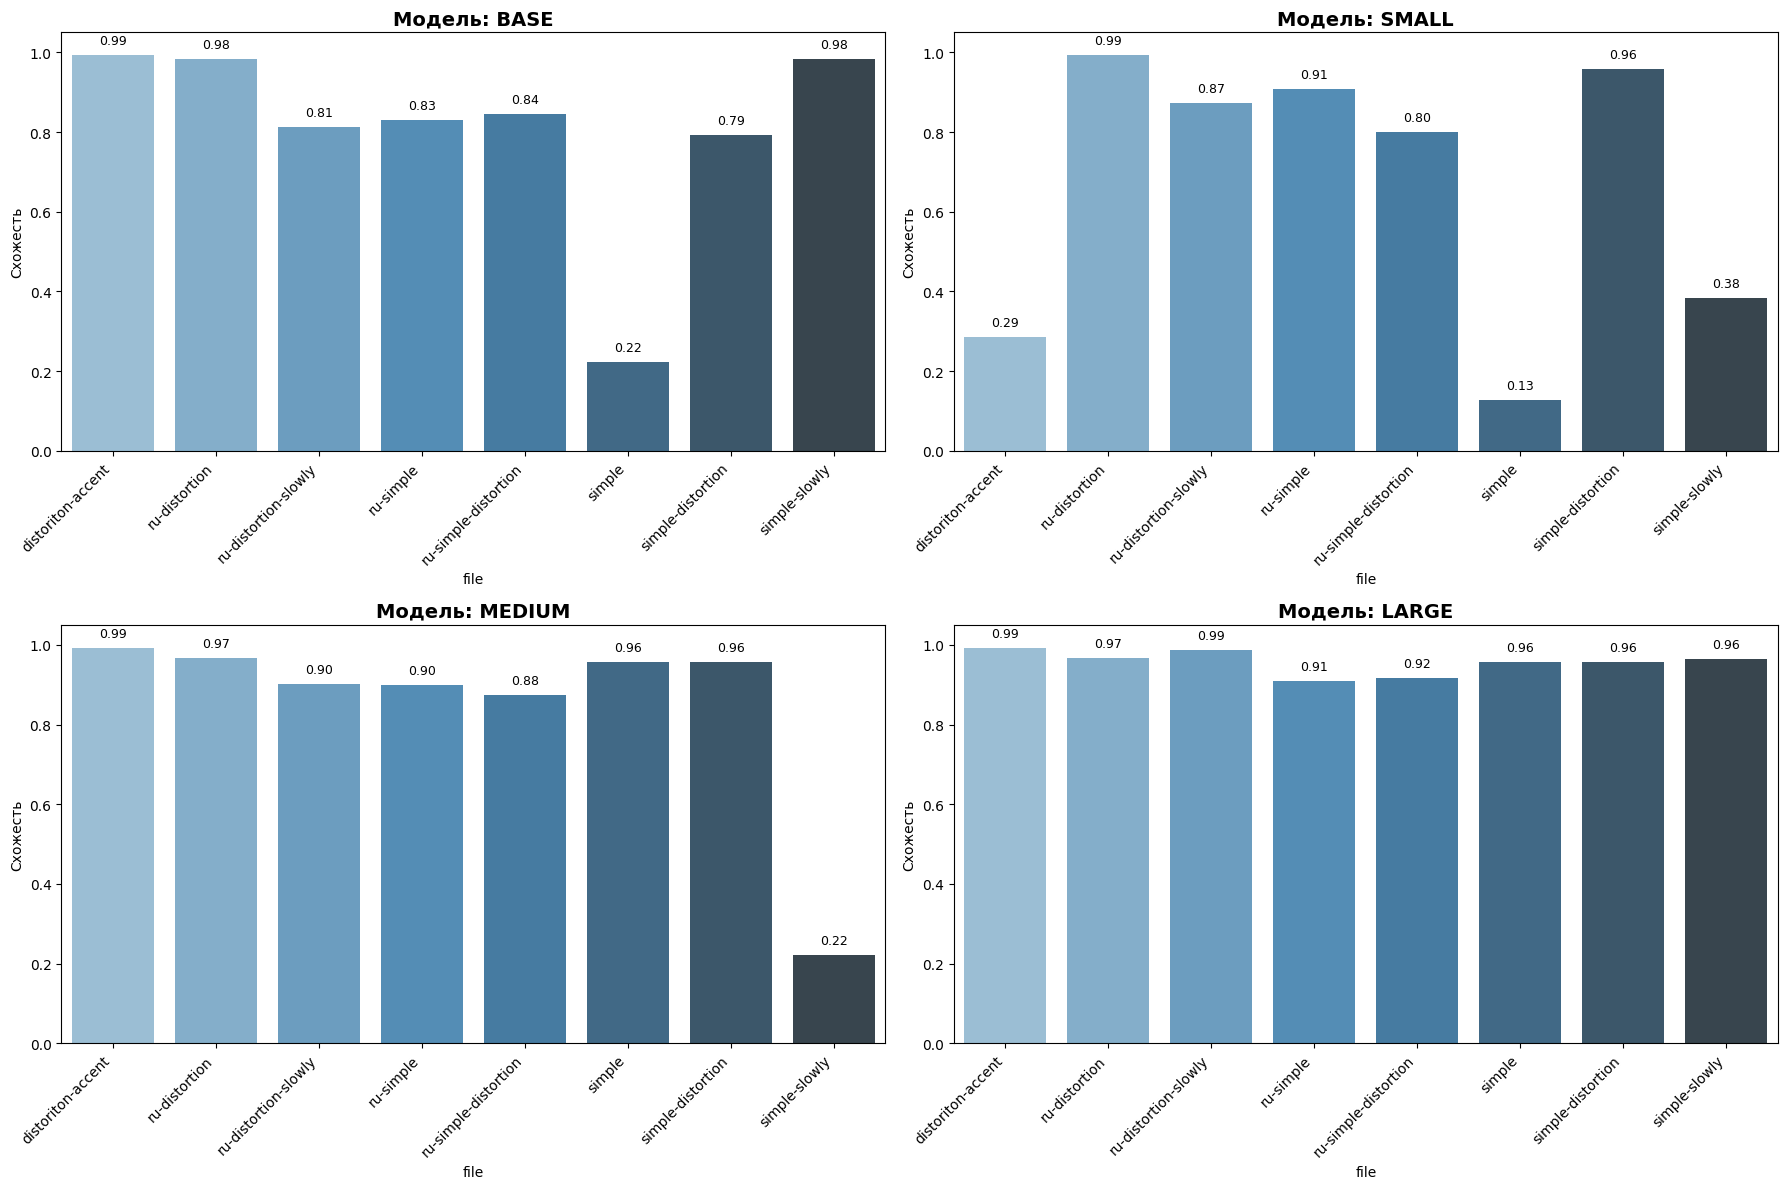

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, model in enumerate(models):
    ax = axes[idx]
    model_data = df[df['model'] == model].copy()

    model_data = model_data.sort_values('file')

    sns.barplot(data=model_data, x='file', y='similarity', ax=ax, palette='Blues_d')

    ax.set_title(f"Модель: {model.upper()}", fontsize=14, weight='bold')
    ax.set_ylabel("Схожесть")
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(model_data['file'], rotation=45, ha='right')

    for i, bar in enumerate(ax.patches):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02,
                f"{height:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2390657943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model', y='similarity', order=models, palette="Set2")


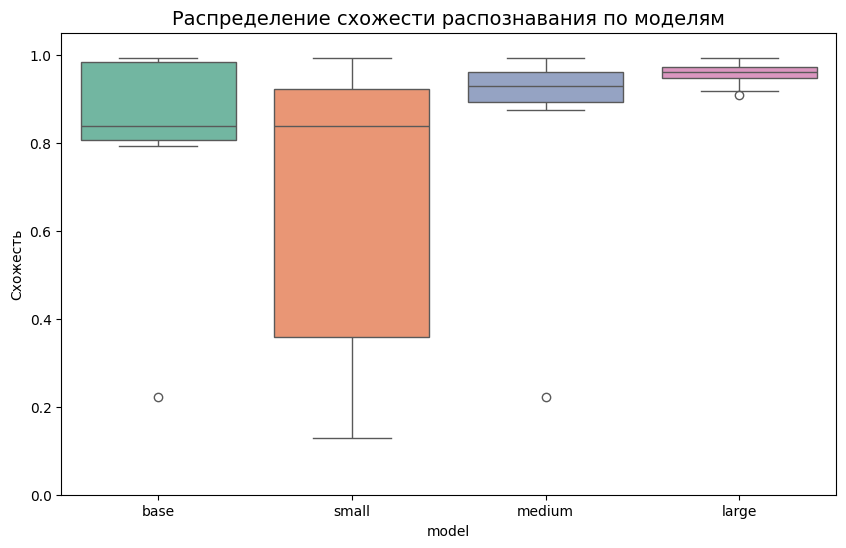

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='model', y='similarity', order=models, palette="Set2")
plt.title("Распределение схожести распознавания по моделям", fontsize=14)
plt.ylabel("Схожесть")
plt.ylim(0, 1.05)
plt.show()

In [23]:
best_worst = df.groupby('model').apply(
    lambda g: pd.Series({
        'best_similarity': g['similarity'].max(),
        'best_file': g.loc[g['similarity'].idxmax(), 'file'],
        'best_predicted': g.loc[g['similarity'].idxmax(), 'predicted'],
        'best_expected': g.loc[g['similarity'].idxmax(), 'expected'],
        'worst_similarity': g['similarity'].min(),
        'worst_file': g.loc[g['similarity'].idxmin(), 'file'],
        'worst_predicted': g.loc[g['similarity'].idxmin(), 'predicted'],
        'worst_expected': g.loc[g['similarity'].idxmin(), 'expected']
    })
).reset_index()

pd.set_option('display.max_colwidth', None)

print("Самый худший и самый лучший результат для каждой модели:\n")
for _, row in best_worst.iterrows():
    print(f"Модель: {row['model'].upper()}")
    print(f"\tЛучший (sim={row['best_similarity']:.3f}) — файл: {row['best_file']}")
    print(f"\tОжидаемо:  {row['best_expected']}")
    print(f"\tРаспознано: {row['best_predicted']}\n")
    print(f"\tХудший (sim={row['worst_similarity']:.3f}) — файл: {row['worst_file']}")
    print(f"\tОжидаемо:  {row['worst_expected']}")
    print(f"\tРаспознано: {row['worst_predicted']}\n")
    print("-" * 80)

Самый худший и самый лучший результат для каждой модели:

Модель: BASE
	Лучший (sim=0.992) — файл: distoriton-accent
	Ожидаемо:  please send me the payment confirmation by the end of the day
	Распознано: Please send me the payment confirmation by the end of the day.

	Худший (sim=0.222) — файл: simple
	Ожидаемо:  hello my name is stepan
	Распознано: – Hello. – Hi, ladies? – Can you and my friend to get used to it? – Yes, Your Highness. – What did you say? – He recommended me some products from the Patreon program

--------------------------------------------------------------------------------
Модель: LARGE
	Лучший (sim=0.992) — файл: distoriton-accent
	Ожидаемо:  please send me the payment confirmation by the end of the day
	Распознано: Please send me the payment confirmation by the end of the day.

	Худший (sim=0.909) — файл: ru-simple
	Ожидаемо:  сегодня прекрасная погода и я иду гулять в парк
	Распознано: Сегодня прекрасная погода и я иду в парк.

----------------------------------

/tmp/ipython-input-2434274363.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_worst = df.groupby('model').apply(


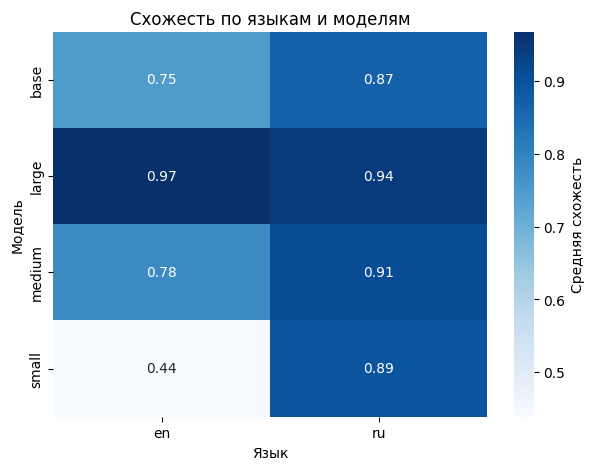

In [22]:
pivot_lang = df.groupby(['model', 'language'])['similarity'].mean().unstack().fillna(0)

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_lang, annot=True, cmap="Blues", cbar_kws={'label': 'Средняя схожесть'})
plt.title("Схожесть по языкам и моделям")
plt.ylabel("Модель")
plt.xlabel("Язык")
plt.show()